# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.

In [44]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [46]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [47]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [48]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.

In [49]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [50]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [51]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [52]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [53]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [54]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

  **Diagnóstico de valores nulos**

**users.city:**
- Tiene 11.7% de valores nulos. Se recomienda investigar si puede imputarse
usando otra información del usuario o dejar como NaN si no afecta el análisis principal.

**users.churn_date:**
- Tiene 88.35% de nulos. Probablemente los nulos indican clientes activos
que no han cancelado el servicio, por lo que no se debe eliminar.

**usage.date:**
- Tiene solamente 0.125% de nulos. Puede imputarse fácilmente o eliminarse
porque representa una proporción muy pequeña.

**usage.duration:**
- Tiene 55.19% de nulos. Probablemente ocurre porque muchos registros son mensajes
y no llamadas, por lo que no necesariamente representa un error.

**usage.length:**
- Tiene 44.74% de nulos. Probablemente ocurre porque muchos registros son llamadas
y no mensajes, por lo que tampoco representa necesariamente un problema de calidad.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [55]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
  - No presenta problemas aparentes. Los IDs están dentro de un rango consistente
y funcionan como identificadores únicos.

- La columna `age` ...
  - Presenta un valor mínimo de -999, lo cual es un sentinel inválido para edad. Se recomienda reemplazarlo por NaN y posteriormente imputar o analizar el caso.

In [56]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
  - Funcionan como identificadores y no muestran inconsistencias aparentes.
    
- La columna `duration`:
  - Tiene valores mínimos de 0 y máximos altos (120). El valor 0 podría representar llamadas fallidas o registros incompletos, por lo que debe investigarse.
 
- La columna `length`:
  - Tiene valores mínimos de 0 y máximos muy altos (1490). Los valores 0 podrían representar mensajes vacíos o errores de captura.

In [57]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col)
    print(users[col].value_counts())
    print()


city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` ...
  - Contiene el valor "?" que funciona como sentinel categórico o dato desconocido. Se recomienda reemplazarlo por NaN.
    
- La columna `plan` ...
  - No presenta inconsistencias; solo contiene las categorías Basico y Premium.

In [58]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...
  - Tiene categorías consistentes ("text" y "call") y no muestra problemas aparentes.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

  - **La columna `user_id`:**
   - *No presenta problemas aparentes. Los IDs están dentro de un rango consistente y funcionan como identificadores únicos.*

  - **La columna `age`:**
   - *Presenta un valor mínimo de -999, lo cual es un sentinel inválido para edad. Se recomienda reemplazarlo por NaN y posteriormente imputar o analizar el caso.*

  - **Las columnas `id` y `user_id` de `usage`:**
   - *Funcionan como identificadores y no muestran inconsistencias aparentes.*

  - **La columna `duration`:**
   - *Tiene valores mínimos de 0 y máximos altos (120). El valor 0 podría representar llamadas fallidas o registros incompletos, por lo que debe investigarse.*

  - **La columna `length`:**
   - *Tiene valores mínimos de 0 y máximos muy altos (1490). Los valores 0 podrían representar mensajes vacíos o errores de captura.*

  - **La columna `city`:**
   - *Contiene el valor "?" que funciona como sentinel categórico o dato desconocido. Se recomienda reemplazarlo por NaN.*

  - **La columna `plan`:**
   - *No presenta inconsistencias; solo contiene las categorías Basico y Premium.*

  - **La columna `type`:**
   - *Tiene categorías consistentes ("text" y "call") y no muestra problemas aparentes.*

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [59]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [60]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [61]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

  - *Aparecen registros del año 2026, lo cual es inválido porque el dataset solamente contiene información hasta 2024.*

In [62]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

 - *Los registros válidos corresponden únicamente al año 2024. No se observan años imposibles ni inconsistencias importantes.*

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Diagnóstico de fechas fuera de rango**

- **En `reg_date`:**
 - *Aparecen registros del año 2026, lo cual es inválido porque el dataset solamente contiene información hasta 2024.*
 - *Se recomienda investigar esos registros y reemplazarlos por NaT o eliminarlos.*

- **En `date`:**
 - *Los registros válidos corresponden únicamente al año 2024.*
 - *No se observan años imposibles ni inconsistencias importantes.*

**Acción recomendada:**
 - *Mantener las fechas válidas de 2022–2024 y tratar los registros de 2026 como errores de captura.*

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [63]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [64]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [65]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [66]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [67]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe tu diagnostico de nulos en `duration` y `length`

- *Los valores nulos en `duration` y `length` sí dependen de la columna `type`, por lo que corresponden a un caso **MAR** (Missing At Random).*

- *Cuando `type` = "`text`", `duration` aparece casi completamente nulo porque los mensajes no tienen duración.*

- *Cuando `type` = "`call`", `length` aparece casi completamente nulo porque las llamadas no tienen longitud de texto.*

- *Por lo tanto, los nulos representan una característica natural del dataset y no un error de captura, así que se recomienda mantenerlos como* **`NaN`.**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [68]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [69]:
# Renombrar columnas
usage_agg.columns = [
    'user_id',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [70]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [71]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [72]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

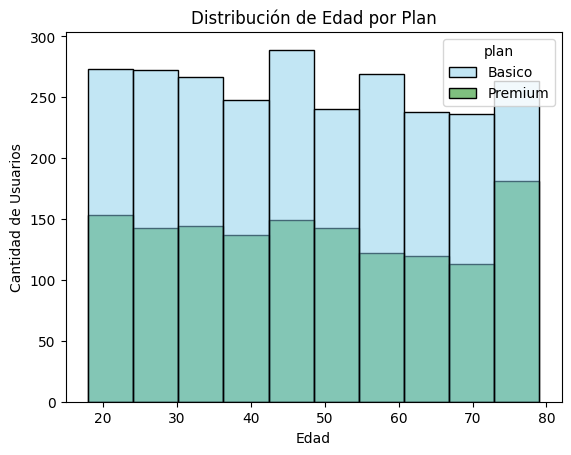

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=10,
    palette=['skyblue', 'green']
)

plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡 **Insights:**
- *La distribución de edades es bastante uniforme tanto en el plan **Basico** como en **Premium**.*
- *No se observa una concentración fuerte en un rango específico de **edad**.*
- *El plan **Basico** tiene mayor cantidad total de usuarios en casi todos los rangos.*
- *No existe una diferencia clara de edad entre usuarios **Basico** y **Premium**.*

📌 **Tipo de distribución:**
- *Distribución relativamente simétrica y uniforme.*
- *No se observan sesgos fuertes ni **outliers** relevantes.*

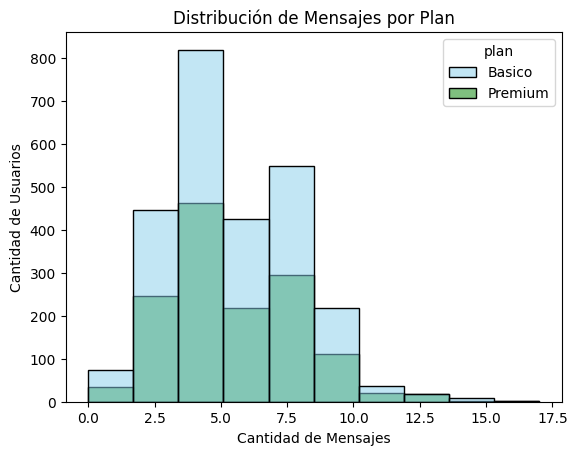

In [74]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    bins=10,
    palette=['skyblue', 'green']
)

plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡 **Insights:**
- *La mayoría de usuarios envía entre 3 y 8 mensajes.*
- *Los usuarios del plan **Basico** presentan mayor volumen total de usuarios.*
- *El comportamiento entre ambos planes es similar, aunque **Premium** parece concentrarse ligeramente en valores medios.*
- *Existen pocos usuarios con cantidades muy altas de mensajes.*
  
📌 **Tipo de distribución:**
- *Distribución sesgada a la derecha **(right-skewed)** .*
- *Hay una cola hacia valores altos de mensajes.*

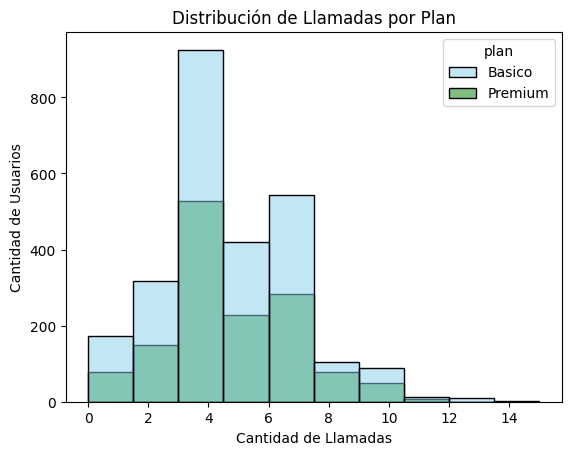

In [75]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    bins=10,
    palette=['skyblue', 'green']
)

plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡 **Insights:**
- *La mayor parte de usuarios realiza entre 3 y 7 llamadas.*
- *El plan **Basico** concentra más usuarios en casi todos los rangos.*
- *Ambos planes muestran patrones de comportamiento muy similares.*
- *Existen pocos usuarios con cantidades altas de llamadas.*
  
📌 **Tipo de distribución:**
- *Distribución sesgada a la derecha **(right-skewed)** .*
- *Se observan algunos valores extremos en llamadas altas.*

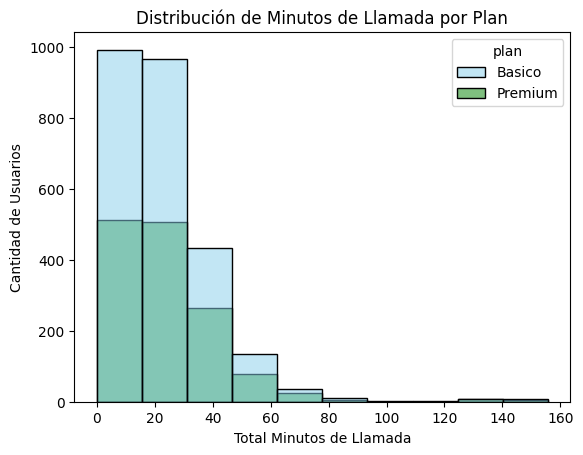

In [76]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    bins=10,
    palette=['skyblue', 'green']
)

plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Total Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡 **Insights:**
- *La mayoría de usuarios consume pocos minutos de llamada, principalmente entre 0 y 40 minutos.*
- *Hay usuarios con consumos extremadamente altos (más de 100 minutos), lo que podría indicar **outliers** o usuarios intensivos.*
- *El plan **Basico** nuevamente presenta mayor cantidad total de usuarios.*
- *El consumo de minutos disminuye rápidamente conforme aumentan los minutos.*

📌 **Tipo de distribución:**
- *Distribución fuertemente sesgada a la derecha **(right-skewed)** .*
- *Se observan **outliers** claros en consumos altos de minutos.*

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

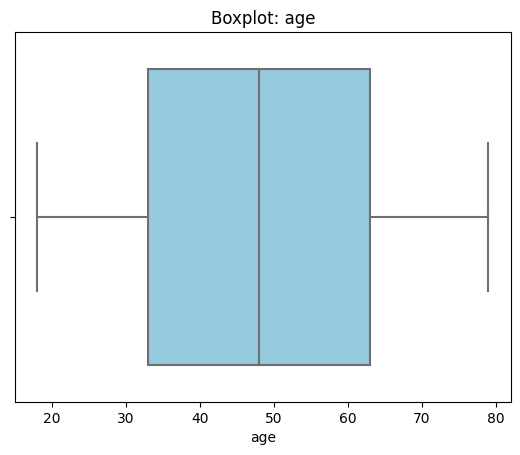

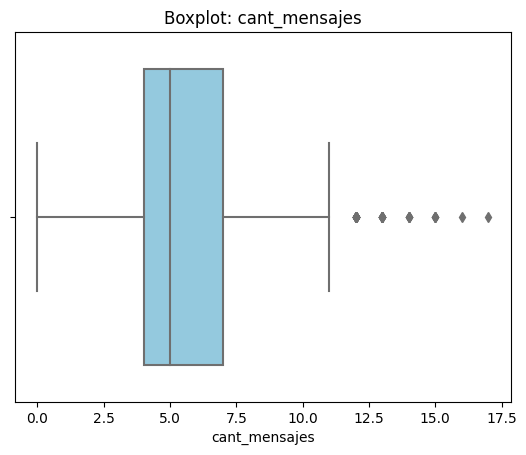

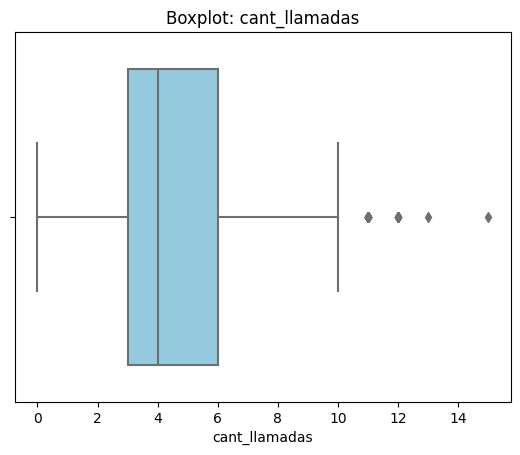

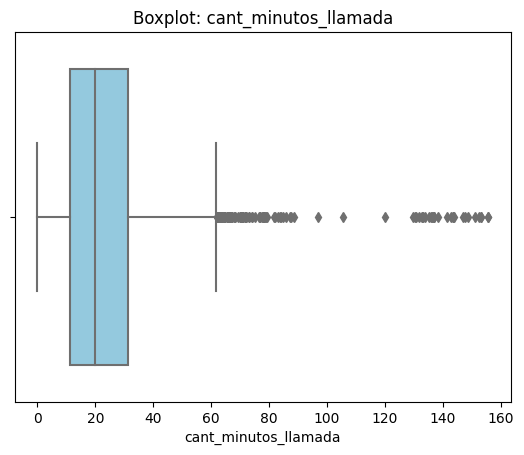

In [77]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡**Insights:** 

📦 **Boxplot: `age`**

🔎 **Análisis:**
- *La variable `age` no presenta outliers visibles.*
- *Después de reemplazar el sentinel `-999` por la **mediana**, las edades quedaron dentro de un rango lógico entre **18** y **79** años.*
- *La **mediana** se encuentra aproximadamente en **48** años y la distribución luce equilibrada.*
  
📌 **Conclusión:**
- *No es necesario aplicar limpieza adicional sobre la variable `age`.*
  
📦 **Boxplot: `cant_mensajes`**

🔎 **Análisis:**
- *Sí existen outliers superiores.*
- *El límite superior calculado con **IQR** es **11.5** mensajes.*
- *El valor máximo observado es **17** mensajes.*
- *Los valores atípicos aparecen únicamente hacia la derecha.*
  
📌 **Conclusión:**
- *Los outliers representan usuarios con actividad alta de mensajería.*
- *Se recomienda mantenerlos, porque pueden reflejar comportamiento real de clientes intensivos y aportan valor al análisis comercial.*
  
📦 **Boxplot: `cant_llamadas`**

🔎 **Análisis:**
- *Sí existen outliers superiores.*
- *El límite superior calculado con **IQR** es **10.5** llamadas.*
- *El valor máximo observado es **15** llamadas.*
- *La mayoría de usuarios se concentra entre **3** y **6** llamadas.*
  
📌 **Conclusión:**
- *Los outliers parecen corresponder a usuarios con uso elevado del servicio.*
- *Se recomienda mantenerlos, ya que podrían representar segmentos premium o usuarios corporativos.*
  
📦 **Boxplot: `cant_minutos_llamada`**

🔎 **Análisis:**
- *Es la variable con mayor cantidad de outliers.*
- *El límite superior calculado con **IQR** es **61.8575** minutos.*
- *El valor máximo observado es **155.69** minutos.*
- *La distribución presenta una cola larga hacia la derecha, indicando fuerte sesgo positivo.*
  
📌 **Conclusión:**
- *Existen usuarios con consumo extremadamente alto de minutos.*
- *Aunque son valores alejados del comportamiento típico, se recomienda conservarlos, ya que pueden representar clientes intensivos y son importantes para análisis de segmentación y optimización de planes.*

In [78]:
# Calcular límites con el método IQR
# Solo se calcula límite superior porque los outliers aparecen únicamente hacia la derecha

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    
    # Calcular cuartiles
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
    # Calcular IQR
    IQR = Q3 - Q1
    
    # Calcular límite superior
    limite_superior = Q3 + 1.5 * IQR
    
    print(f'Columna: {col}')
    print('Limite superior:', limite_superior)
    print('Valor máximo:', user_profile[col].max())
    print()
    


Columna: cant_mensajes
Limite superior: 11.5
Valor máximo: 17.0

Columna: cant_llamadas
Limite superior: 10.5
Valor máximo: 15.0

Columna: cant_minutos_llamada
Limite superior: 61.8575
Valor máximo: 155.69



In [79]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡**Insights:** 
- **cant_mensajes: mantener o no outliers, porqué?**
  *presenta outliers superiores, pero se recomienda mantenerlos porque representan usuarios con alta actividad de mensajería y no parecen errores de captura.*
  
- **cant_llamadas: mantener o no outliers, porqué?**
  *presenta outliers superiores relacionados con usuarios que realizan muchas llamadas. Se conservarán porque reflejan comportamiento real de clientes intensivos.*

- **cant_minutos_llamada: mantener o no outliers, porqué?**
  *presenta la mayor cantidad de outliers y una fuerte cola derecha. Se mantendrán porque son útiles para identificar usuarios de alto consumo y posibles segmentos premium.*

  📊 **Conclusión General de Outliers**
- *Los outliers encontrados aparecen principalmente en variables de comportamiento de uso:*
  - `cant_mensajes`
  - `cant_llamadas`
  - `cant_minutos_llamada`
- *Todos los outliers se encuentran en el extremo superior de las distribuciones.*
- *No parecen errores de captura, sino comportamientos reales de usuarios intensivos.*
- *Por ello:*
  - *No se eliminarán*
  - *No se imputarán*
  - *Se conservarán para futuras segmentaciones y análisis de negocio.*

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [83]:
import numpy as np
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'))

In [84]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [85]:
# Crear columna grupo_edad

user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'))

In [86]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

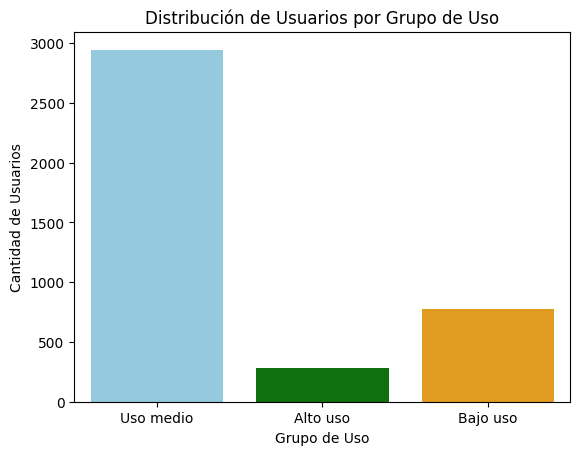

In [87]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'green', 'orange'])

plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

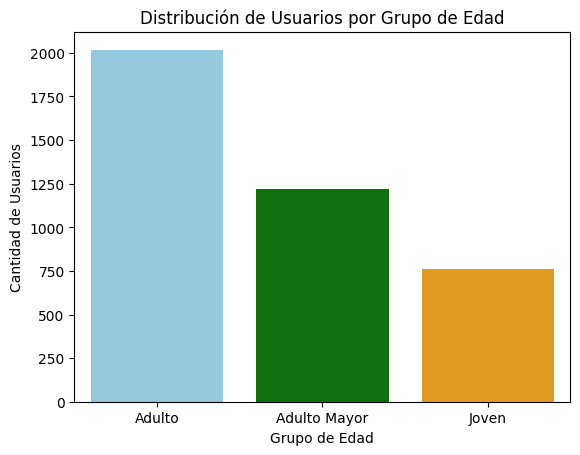

In [88]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'green', 'orange'])

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

*Durante la exploración inicial se identificaron múltiples problemas de calidad que podían afectar el análisis del comportamiento de los clientes.*

*En el dataset `users`, la columna `city` presentaba aproximadamente un **11.7%** de valores*  *faltantes y registros inválidos representados por  `"?"`. Estos valores fueron reemplazados por `NaN` para evitar clasificaciones incorrectas por ciudad.*

*La columna **`churn_date`** presentó cerca del **88%** de valores nulos. Sin embargo, este comportamiento es consistente con clientes que continúan activos, por lo que los nulos se mantuvieron sin imputar.*

*En la columna **`age`** se detectó el valor sentinel `-999`, el cual representa un error de captura. Este valor fue reemplazado por la **mediana** de edad para mantener la distribución estable y evitar distorsiones estadísticas.*

*En el dataset `usage`, las columnas* `duration` y `length` *tenían aproximadamente* **55%** y **45%** *de valores nulos respectivamente. Después de revisar la variable `type`, se confirmó que estos nulos eran **MAR** (Missing At Random), ya que:*

 - *`duration` solo aplica para llamadas (`call`)*
 - *`length` solo aplica para mensajes (`text`)*

*Por esta razón, los valores faltantes se conservaron como nulos y no fueron imputados.*

*También se identificaron fechas futuras en `reg_date` correspondientes al año 2026, aunque el análisis se limita hasta 2024. Estas fechas fueron marcadas como nulas por considerarse errores de captura.*


🔍 **Segmentos por Edad**

*Se identificaron tres segmentos principales de usuarios:*

- **Jóvenes:** *menores de 30 años.*
- **Adultos:** *entre 30 y 59 años.*
- **Adultos Mayores:** *60 años o más.*

*El grupo predominante dentro de la base corresponde a los usuarios adultos, lo que indica que la mayor parte de la cartera de clientes se encuentra en edades económicamente activas y con mayor estabilidad de consumo.*

*Los usuarios jóvenes muestran comportamientos más variables y una mayor dispersión en mensajes y llamadas, mientras que los adultos mayores presentan un patrón más estable y moderado de uso.*


📊 **Segmentos por Nivel de Uso**

*Los clientes fueron clasificados en tres segmentos según llamadas y mensajes:*

- **Bajo uso**
- **Uso medio**
- **Alto uso**

*La mayoría de usuarios se concentra en el segmento de **Uso medio**, indicando que el comportamiento típico del cliente utiliza moderadamente los servicios móviles.*

*El segmento de **Alto uso** representa una proporción menor, pero estratégica para la empresa, ya que concentra usuarios con mayor consumo de llamadas y mensajes, lo que podría generar mayores ingresos o necesidades de planes premium.*

*Los usuarios de **Bajo uso** podrían representar oportunidades de retención, migración a planes más económicos o campañas de reactivación.*

➡️ *Esto sugiere que el comportamiento de consumo no es homogéneo y que existen grupos claramente diferenciados que requieren estrategias comerciales específicas.*


🚨 **Patrones de uso extremo (Outliers)**

*Se identificaron valores atípicos en:*

- **cantidad de mensajes,**
- **cantidad de llamadas,**
- **minutos totales de llamada.**

*Los outliers aparecen principalmente en la cola superior de la distribución, indicando usuarios con niveles de consumo significativamente mayores al promedio.*

**Por ejemplo:**

- `cant_mensajes` *alcanzó valores máximos de **17** mensajes frente a un límite **IQR** aproximado de **11.5**.*
- `cant_llamadas` *alcanzó **15** llamadas frente a un límite de* **10.5**.
- `cant_minutos_llamada` *alcanzó más de **155** minutos frente a un límite aproximado de **61.8**.*

*Estos valores no fueron eliminados porque representan comportamientos plausibles dentro del negocio de telecomunicaciones y podrían corresponder a:*

- **clientes intensivos,**
- **usuarios corporativos,**
- **clientes premium,**
- **o segmentos de alto valor comercial.**

*Eliminar estos registros habría reducido la capacidad de identificar oportunidades de monetización y personalización de planes.*


💡 **Recomendaciones**

- *Diseñar planes diferenciados según nivel de uso, especialmente para usuarios de alto consumo.*
- *Crear paquetes específicos para usuarios jóvenes, priorizando beneficios de mensajería y comunicación frecuente.*
- *Implementar estrategias de **upselling** hacia clientes de **Uso medio** que muestran potencial de crecimiento.*
- *Evaluar planes económicos o flexibles para usuarios de **Bajo uso** y así reducir churn.*
- *Monitorear continuamente los usuarios con consumo extremo para detectar oportunidades comerciales o posibles anomalías operativas.*
- *Fortalecer los procesos de captura y validación de datos para evitar sentinels, fechas futuras y valores inválidos.*

*En general, **ConnectaTel** cuenta con segmentos claramente diferenciados de clientes, lo que abre oportunidades para personalizar productos, optimizar ingresos y mejorar la experiencia del usuario mediante estrategias basadas en los hallazgos.*

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`